# Cassini UVIS Python Package (Cassini_UPyP)

In this example notebook (copy the code on a regular Python script if preferred) we present a simple data processing and analysis of a Titan flyby. Data files are located in the data folder provided.

In [1]:
from cassini_upyp import UVIS_Observation
from pathlib import Path

### 1. Reading the raw files

In [2]:
datafolder = Path('./data')

datafiles = list(datafolder.iterdir())

print("Reading following files :")
for file in datafiles:
    print('>', file.name)

obs = UVIS_Observation(datafiles, prime_instrument='UVIS', target='Titan')

print('\nUVIS_Observation object created :',obs.name)
print(f' - Number of exposures : {obs.n_pics}')
print(f' - Date of start (UTC) : {obs.UTC_start[0]}')   # Start is the start of exposures
print(f' - Date of end (UTC)   : {obs.UTC_stop[-1]}\n') # Stop is the end of exposures


print('Main data cube with shape:', obs.data.shape)  # (n_exposures, n_spatial_pixels, n_spectral_pixels)

Reading following files :
> FUV2006_015_19_11_PRIME.LBL
> FUV2006_015_15_51_PRIME.DAT
> FUV2006_015_17_59_PRIME.LBL
> FUV2006_015_16_55_PRIME.DAT
> FUV2006_015_14_47_PRIME.DAT
> FUV2006_015_14_47_PRIME.LBL
> FUV2006_015_16_55_PRIME.LBL
> FUV2006_015_19_11_PRIME.DAT
> FUV2006_015_15_51_PRIME.LBL
> FUV2006_015_17_59_PRIME.DAT
> FUV2006_015_19_03_PRIME.LBL
> FUV2006_015_19_03_PRIME.DAT

UVIS_Observation object created : FUV_2006_015_PRIME
 - Number of exposures : 69
 - Date of start (UTC) : 2006-015T14:43:41.235
 - Date of end (UTC)   : 2006-015T19:39:59.258

Main data cube with shape: (69, 60, 1024)


### 2. Computing geometry

The geometry can be computed for a given spacecraft time with `obs.get_geometry(time)` or with `obs.set_geometry()` where it computes geometry for all exposures and their corresponding time. `obs.set_geometry()` does not provide the geometry python objects and cannot be used to plot.
This section uses NAIF SPICE Kernels.

In [ ]:
# Plotting geometry of the first exposure
%matplotlib inline
ET = obs.ET_start[0]     # ET of the start of the first exposure
g = obs.get_geometry(ET) # Get the Geometry object
g.plot()

### 3. UV Image and star contamination identification

`obs.check_stars()` allows to click on the widget to mark pixels as contaminated. The pixels are stored in memory, so that the function can be called multiple times and will display the latest registered list of pixel.

In [4]:
%matplotlib qt
# ^ Specific to notebook, to have interactive plots in a separate window with QT backend

obs.check_stars(wl_range=(1600,1900))

### 4. Background noise determination

In [5]:
obs.set_geometry() # Compute geometry for all exposures and stores information like pixel positions, required for advanced processing.
obs.set_background(alt_limit=2000) # Set background using altitudes above 2000 km

print(f'Background noise level: {obs.background_level:.4} counts/second')

Computing geometry: 100%|██████████| 69/69 [00:07<00:00,  8.72it/s]
Background noise level: 0.0005127 counts/second


### 5. Calibration

In [6]:
obs.calibrate()

Applying calibration... Done


Properties of pixel 25 center, in exposure 20:
    Altitude        : 699.53 km
    Latitude        : -39.24°
    Longitude       : 72.46°
    Phase angle     : 144.94°
    Incidence angle : 55.32°


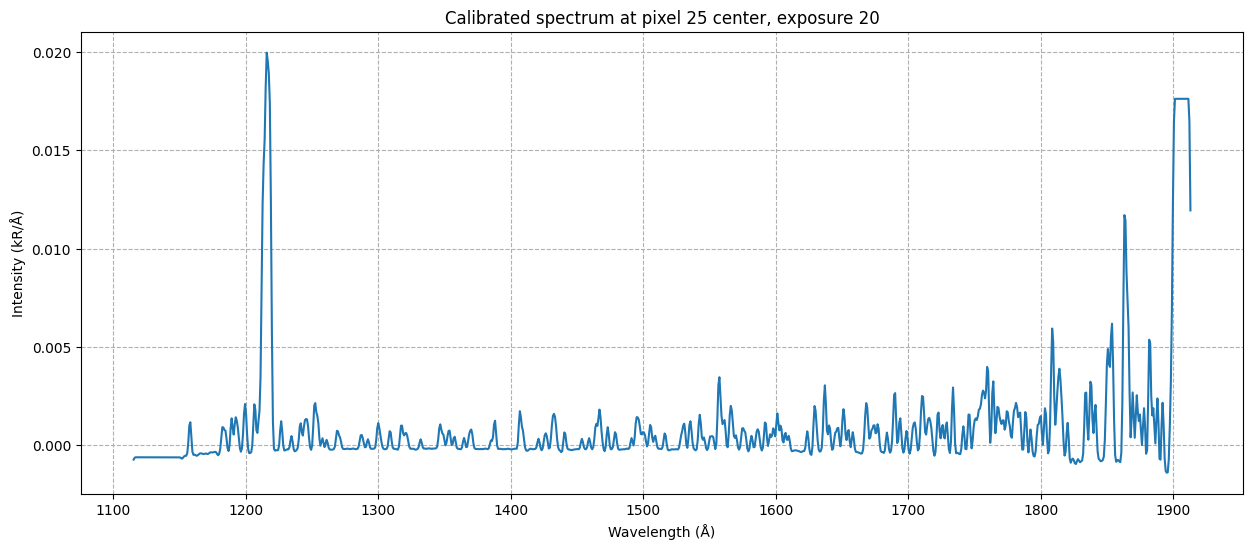

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(15,6))
plt.plot(obs.WL, obs.data[20,25])

print(f"Properties of pixel 25 center, in exposure 20:")
print(f"    Altitude        : {obs.pixel_LOS[20,25,0]['alt']:.2f} km")
print(f"    Latitude        : {obs.pixel_LOS[20,25,0]['lat']:.2f}°")
print(f"    Longitude       : {obs.pixel_LOS[20,25,0]['lon']:.2f}°")
print(f"    Phase angle     : {obs.pixel_LOS[20,25,0]['phase']:.2f}°")
print(f"    Incidence angle : {obs.pixel_LOS[20,25,0]['sza']:.2f}°")

plt.xlabel('Wavelength (Å)')
plt.ylabel('Intensity (kR/Å)')

plt.title('Calibrated spectrum at pixel 25 center, exposure 20')
plt.grid(ls='--')
plt.show()

### 6. Binning the data

Binning pixels can be done in two ways, either manually by defining a list of pixels to bin together, either by defining a set of geometrical properties on a given grid.

Creating bins... Done


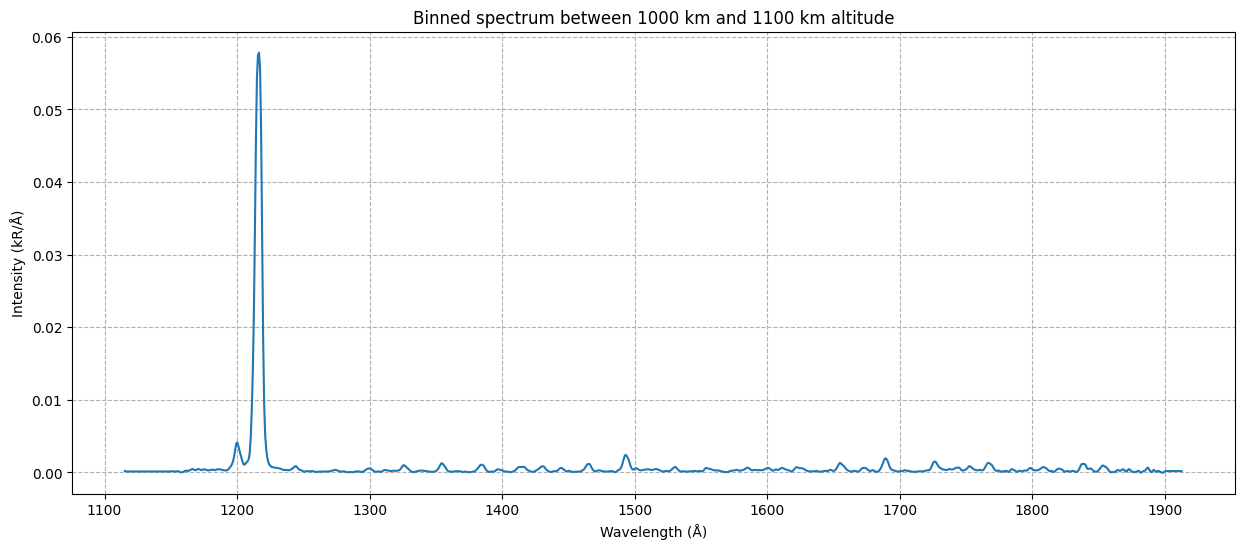

In [8]:
# Bin all pixels between 1000 km and 1100 km altitude
alt_min = 1000  # km
alt_max = 1100  # km

bin_1 = obs.bin_pixels(bin_boundaries=[(alt_min, alt_max)], keys=['alt'])

bin_1.average()

plt.figure(figsize=(15,6))
plt.plot(bin_1.WL, bin_1.bin_mean_spectrum[0]) # Index 0 corresponds to first (and only) bin

plt.xlabel('Wavelength (Å)')
plt.ylabel('Intensity (kR/Å)')
plt.title(f'Binned spectrum between {alt_min} km and {alt_max} km altitude')
plt.grid(ls='--')
